In [6]:
#Random Forest, Gradient Boosting, XGBoost, and SVM


Random Forest:
Train R²: 0.6572
Test R²: 0.2314
Train RMSE: 30.8195
Test RMSE: 46.6287
Train MAE: 18.1601
Test MAE: 27.9170


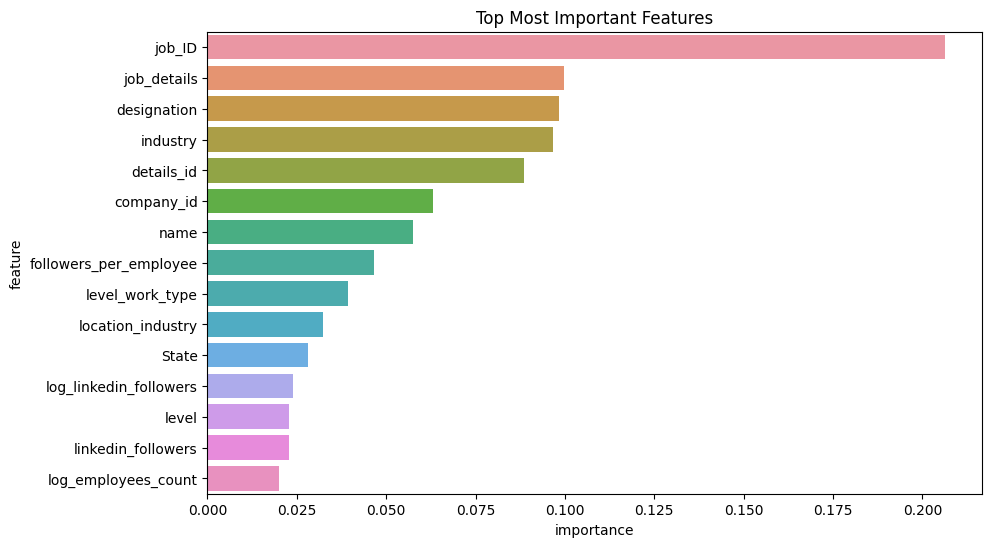


Support Vector Machine:
Train R²: -0.1114
Test R²: -0.1291
Train RMSE: 55.4931
Test RMSE: 56.5169
Train MAE: 23.3058
Test MAE: 24.7471
Feature importance is not available for this model.

Gradient Boosting:
Train R²: 0.8105
Test R²: 0.2256
Train RMSE: 22.9173
Test RMSE: 46.8034
Train MAE: 13.6681
Test MAE: 28.0596


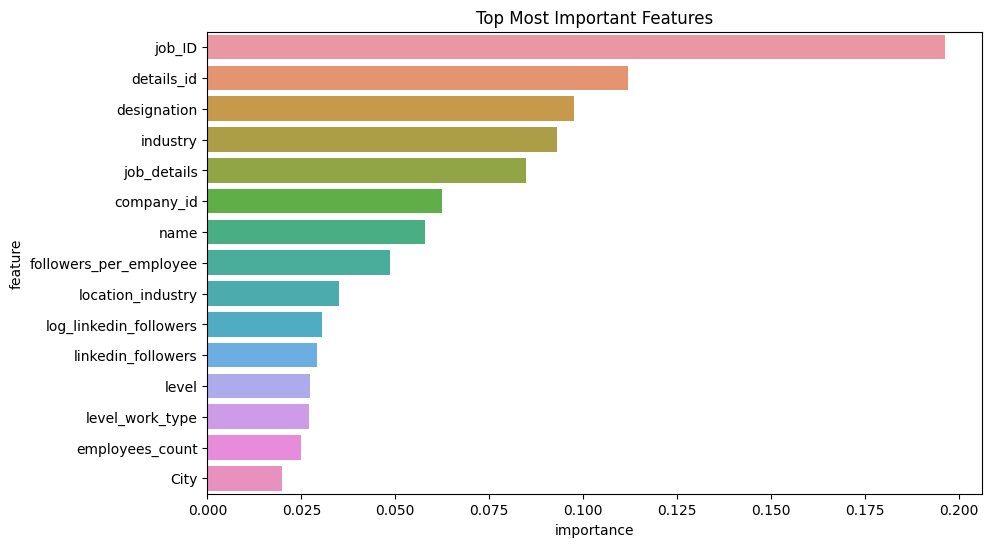


XGBoost:
Train R²: 0.3772
Test R²: 0.2288
Train RMSE: 41.5419
Test RMSE: 46.7079
Train MAE: 25.0354
Test MAE: 28.6382


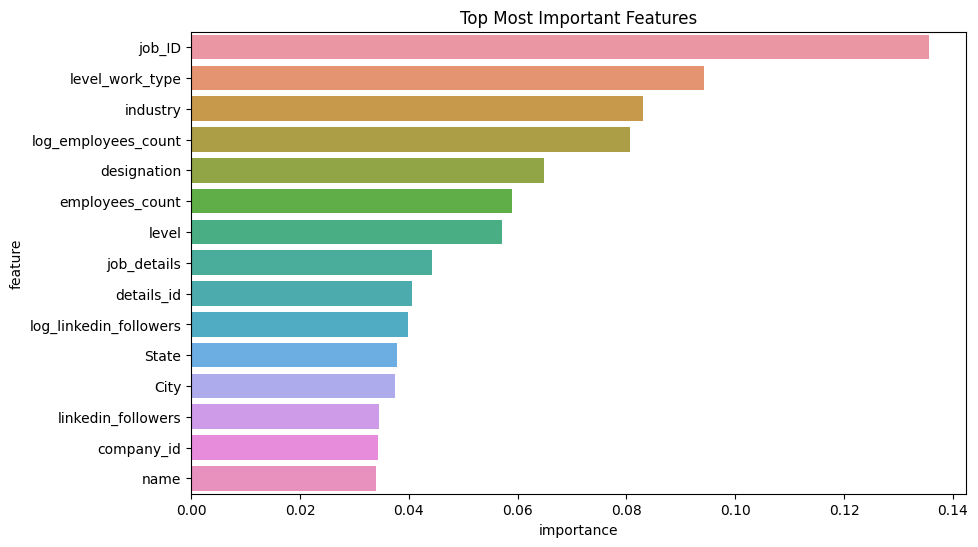

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

# 1. Load and prepare the data
def load_and_prepare_data(file_path):
    # Read the data
    job_data = pd.read_csv(file_path)
    return job_data

# 2. Data preprocessing
def preprocess_data(df):
    # Create a copy to avoid modifying original data
    processed_df = df.copy()
    
    # Handle missing values if any
    numeric_columns = processed_df.select_dtypes(include=['float64', 'int64']).columns
    for col in numeric_columns:
        processed_df[col].fillna(processed_df[col].median(), inplace=True)
    
    # Encode categorical variables
    encoder = LabelEncoder()
    categorical_columns = ['job_ID', 'designation', 'company_id', 'name', 'work_type', 
                           'involvement', 'job_details', 'details_id', 'industry', 
                           'level', 'City', 'State']
    
    for col in categorical_columns:
        if col in processed_df.columns:
            processed_df[col] = encoder.fit_transform(processed_df[col].astype(str))
    
    return processed_df

# 3. Feature engineering
def engineer_features(df):
    # Create a copy
    featured_df = df.copy()
    
    # Create interaction features for important numerical columns
    featured_df['followers_per_employee'] = featured_df['linkedin_followers'] / (featured_df['employees_count'] + 1)
    
    # Create categorical interaction features
    featured_df['location_industry'] = featured_df['City'] * featured_df['industry']
    featured_df['level_work_type'] = featured_df['level'] * featured_df['work_type']
    
    # Log transform for skewed numerical features
    featured_df['log_linkedin_followers'] = np.log1p(featured_df['linkedin_followers'])
    featured_df['log_employees_count'] = np.log1p(featured_df['employees_count'])
    
    return featured_df

# 4. Model training and evaluation
def train_and_evaluate_model(model, X_train, X_test, y_train, y_test):
    # Train the model
    model.fit(X_train, y_train)
    return model

# 5. Model evaluation metrics
def evaluate_model(model, X_train, X_test, y_train, y_test):
    # Make predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Calculate metrics
    metrics_dict = {
        'Train R²': metrics.r2_score(y_train, train_pred),
        'Test R²': metrics.r2_score(y_test, test_pred),
        'Train RMSE': np.sqrt(metrics.mean_squared_error(y_train, train_pred)),
        'Test RMSE': np.sqrt(metrics.mean_squared_error(y_test, test_pred)),
        'Train MAE': metrics.mean_absolute_error(y_train, train_pred),
        'Test MAE': metrics.mean_absolute_error(y_test, test_pred)
    }
    
    return metrics_dict

# 6. Feature importance visualization
def plot_feature_importance(model, X):
    if hasattr(model, 'feature_importances_'):
        # Get feature importance
        importance = model.feature_importances_
        features = X.columns
        
        # Create DataFrame for visualization
        feature_importance = pd.DataFrame({
            'feature': features,
            'importance': importance
        }).sort_values('importance', ascending=False)
        
        # Plot
        plt.figure(figsize=(10, 6))
        sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
        plt.title('Top Most Important Features')
        plt.show()
        
        return feature_importance
    else:
        print("Feature importance is not available for this model.")
        return None

# 7. Main execution
def main():
    # Load data
    job_data = load_and_prepare_data('/kaggle/input/data-new/job_cleanData.csv')
    
    # Preprocess data
    processed_data = preprocess_data(job_data)
    
    # Engineer features
    featured_data = engineer_features(processed_data)
    
    # Prepare features and target
    X = featured_data.drop(['total_applicants'], axis=1)
    y = featured_data['total_applicants']
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )
    
    # Define models
    models = {
        'Random Forest': RandomForestRegressor(
            n_estimators=200, max_depth=10, random_state=42, min_samples_split=5, min_samples_leaf=2
        ),
        'Support Vector Machine': SVR(C=1.0, kernel='rbf', gamma='scale', epsilon=0.1),
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.1, max_depth=5, subsample=0.8, random_state=42
        ),
        'XGBoost': XGBRegressor(
            n_estimators=200, max_depth=5, learning_rate=0.01, min_child_weight=3,
            subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=42
        )
    }
    
    # Train and evaluate models
    for name, model in models.items():
        print(f"\n{name}:")
        trained_model = train_and_evaluate_model(model, X_train, X_test, y_train, y_test)
        metrics_dict = evaluate_model(trained_model, X_train, X_test, y_train, y_test)
        for metric, value in metrics_dict.items():
            print(f"{metric}: {value:.4f}")
        
        # Plot feature importance if available
        plot_feature_importance(trained_model, X)

if __name__ == "__main__":
    main()
